# CLAP Metamer Debug Notebook

This notebook generates a metamer for the **CLAP audio encoder** model one block at a time.

Workflow blocks:
1. Setup and imports
2. User-configurable settings
3. Load and prepare an audio clip
4. Load CLAP and inspect metamer layers
5. Extract target representation
6. Run metamer optimization loop
7. Inspect diagnostics
8. Save artifacts

All logic is kept inline in cells (no helper functions yet) so each stage is easy to debug.

In [1]:
# Block 1: setup and imports
from pathlib import Path
import io
import json
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

from src.models.audio.registry import get_audio_model, list_audio_models

In [2]:
# Block 2: user-configurable settings
# Input mode options:
# - "tfrecord_first_audioset_split": pull first example from first AudioSet split
# - "wav_path": load AUDIO_PATH directly
INPUT_SOURCE = "tfrecord_first_audioset_split"

# Used when INPUT_SOURCE == "wav_path"
AUDIO_PATH = Path("/path/to/your/audio.wav")

# Used when INPUT_SOURCE == "tfrecord_first_audioset_split"
AUDIOSET_ROOT = Path("/home/rphess/orcd/datasets/AudioSet")
AUDIOSET_SPLIT_GLOB = "audioset-2m-part*"
TFRECORD_GLOB = "*.tfrecords"
TFRECORD_EXAMPLE_INDEX = 2  # zero-indexed; 1 means the second example

# Sampling and clip settings
INPUT_SAMPLE_RATE_OVERRIDE = None  # set int to force known sr, else use source sr
TARGET_SAMPLE_RATE = 48_000
CLIP_SECONDS = 2.0
START_SECONDS = 0.0

# Model/layer settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AUDIO_MODEL_NAME = "clap"
LAYER_NAME = "transformer_block_05"  # None means pick the first metamer layer

# Optimization settings
SEED = 42
LOSS_TYPE = "normalized_l2"  # one of: normalized_l2, l2, cosine
LR = 0.25
NUM_ROUNDS = 4
STEPS_PER_ROUND = 200
LR_DECAY = 0.7
NOISE_SCALE = 0.01
NOISE_MEAN = 0.0
CLAMP_MIN = -1.0
CLAMP_MAX = 1.0

# Output settings
OUTPUT_ROOT = Path("experiments/audio/clap/metamers_debug")
RUN_TAG = time.strftime("%Y%m%d_%H%M%S")

In [3]:
# Block 3: quick environment checks
print("Device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("Registered audio models:", list_audio_models())
print("Input source:", INPUT_SOURCE)

if AUDIO_MODEL_NAME != "clap":
    raise ValueError(
        "This notebook is for CLAP metamer debugging. "
        "Set AUDIO_MODEL_NAME = 'clap'."
    )

if INPUT_SOURCE == "wav_path":
    if not AUDIO_PATH.exists():
        raise FileNotFoundError(
            f"AUDIO_PATH does not exist: {AUDIO_PATH}. "
            "Update AUDIO_PATH before continuing."
        )
elif INPUT_SOURCE == "tfrecord_first_audioset_split":
    if not AUDIOSET_ROOT.exists():
        raise FileNotFoundError(
            f"AudioSet root not found: {AUDIOSET_ROOT}. Update AUDIOSET_ROOT."
        )
else:
    raise ValueError(
        f"Unsupported INPUT_SOURCE: {INPUT_SOURCE}. "
        "Use 'tfrecord_first_audioset_split' or 'wav_path'."
    )

Device: cuda
CUDA available: True
Registered audio models: ['audiomae', 'audiomae_as2m', 'audiomae_as2m_ft_as20k', 'beats', 'beats_iter3', 'beats_iter3_plus_as2m', 'clap', 'maskspec', 'ssast']
Input source: tfrecord_first_audioset_split


In [4]:
# Block 4: load waveform and build [B, 1, T] tensor
source_info = {}

if INPUT_SOURCE == "wav_path":
    file_sr, waveform_np = wavfile.read(str(AUDIO_PATH))
    source_info["input_source"] = INPUT_SOURCE
    source_info["audio_path"] = str(AUDIO_PATH)

elif INPUT_SOURCE == "tfrecord_first_audioset_split":
    try:
        from tfrecord.reader import example_loader
    except ImportError as exc:
        raise ImportError(
            "Missing dependency 'tfrecord'. Install it in this environment with: "
            "python -m pip install tfrecord"
        ) from exc

    split_dirs = sorted(AUDIOSET_ROOT.glob(AUDIOSET_SPLIT_GLOB))
    if len(split_dirs) == 0:
        raise FileNotFoundError(
            f"No split dirs matched {AUDIOSET_SPLIT_GLOB!r} under {AUDIOSET_ROOT}"
        )

    first_split_dir = split_dirs[0]
    tfrecord_paths = sorted(first_split_dir.glob(TFRECORD_GLOB))
    if len(tfrecord_paths) == 0:
        raise FileNotFoundError(
            f"No TFRecords matched {TFRECORD_GLOB!r} under {first_split_dir}"
        )

    first_tfrecord = tfrecord_paths[0]
    tfrecord_examples = example_loader(
        str(first_tfrecord),
        index_path=None,
        description=None,
        compression_type="gzip",
    )
    first_example = None
    for example_idx, candidate_example in enumerate(tfrecord_examples):
        if example_idx == TFRECORD_EXAMPLE_INDEX:
            first_example = candidate_example
            break
    if first_example is None:
        raise IndexError(
            f"TFRecord example index {TFRECORD_EXAMPLE_INDEX} was not found in "
            f"{first_tfrecord}."
        )

    if "audio" not in first_example:
        raise KeyError(
            f"Expected 'audio' bytes in first record. Keys: {sorted(first_example.keys())}"
        )

    audio_bytes = first_example["audio"]
    file_sr, waveform_np = wavfile.read(io.BytesIO(audio_bytes))

    ytid_value = first_example.get("ytid", b"")
    if isinstance(ytid_value, bytes):
        ytid_value = ytid_value.decode("utf-8", errors="replace")

    labels_value = first_example.get("labels")
    labels_list = []
    if labels_value is not None:
        labels_list = [int(x) for x in labels_value.tolist()]

    source_info["input_source"] = INPUT_SOURCE
    source_info["audioset_root"] = str(AUDIOSET_ROOT)
    source_info["first_split_dir"] = str(first_split_dir)
    source_info["first_tfrecord"] = str(first_tfrecord)
    source_info["tfrecord_example_index"] = int(TFRECORD_EXAMPLE_INDEX)
    source_info["ytid"] = ytid_value
    source_info["labels"] = labels_list

    print("Using first split:", first_split_dir)
    print("Using first TFRecord:", first_tfrecord.name)
    print("Using TFRecord example index:", TFRECORD_EXAMPLE_INDEX)
    print("Selected example ytid:", ytid_value)
    print("Selected example labels:", labels_list)

else:
    raise ValueError(f"Unsupported INPUT_SOURCE: {INPUT_SOURCE}")

# Convert decoded waveform to torch [C, T] float32 in [-1, 1].
if waveform_np.ndim == 1:
    waveform_np = waveform_np[:, None]

if np.issubdtype(waveform_np.dtype, np.integer):
    waveform = torch.from_numpy(waveform_np.astype(np.float32))
    max_int = float(np.iinfo(waveform_np.dtype).max)
    waveform = waveform / max_int
else:
    waveform = torch.from_numpy(waveform_np.astype(np.float32))

# wavfile.read gives [T, C]; transpose to [C, T]
waveform = waveform.transpose(0, 1).contiguous()

if INPUT_SAMPLE_RATE_OVERRIDE is not None:
    file_sr = int(INPUT_SAMPLE_RATE_OVERRIDE)

# Convert to mono by averaging channels.
if waveform.dim() != 2:
    raise RuntimeError(f"Expected waveform shape [C, T], got {tuple(waveform.shape)}")
waveform_mono = waveform.mean(dim=0, keepdim=True)

# Slice a clip for debugging speed.
start_sample = int(START_SECONDS * file_sr)
clip_samples = int(CLIP_SECONDS * file_sr)
end_sample = start_sample + clip_samples
waveform_clip = waveform_mono[:, start_sample:end_sample]

if waveform_clip.shape[-1] == 0:
    raise RuntimeError("Empty clip after slicing. Adjust START_SECONDS/CLIP_SECONDS.")

# Build canonical waveform [B, 1, T] for bookkeeping/display.
original_waveform = waveform_clip.unsqueeze(0).to(DEVICE)

# CLAP wrapper consumes [B, T] waveforms and handles resampling/features internally.
original_waveform_model = original_waveform.squeeze(1)

print("Loaded waveform:", tuple(waveform.shape), "sr=", file_sr)
print("Clip waveform [B,1,T]:", tuple(original_waveform.shape))
print("Model waveform [B,T]:", tuple(original_waveform_model.shape))

display(Audio(original_waveform[0, 0].detach().cpu().numpy(), rate=file_sr))

Using first split: /home/rphess/orcd/datasets/AudioSet/audioset-2m-part00
Using first TFRecord: unbalanced_train_segments_part00_chunk00_4096.tfrecords
Using TFRecord example index: 2
Selected example ytid: -133PLpY0yw
Selected example labels: [0]
Loaded waveform: (1, 320031) sr= 32000
Clip waveform [B,1,T]: (1, 1, 64000)
Model waveform [B,T]: (1, 64000)


In [10]:
# Block 5: load CLAP and inspect layers
model = get_audio_model(AUDIO_MODEL_NAME, device=DEVICE, freeze=True)
model.eval()

print(type(model))
print("metamer_layers count:", len(model.metamer_layers))
print("first 10 metamer layers:", model.metamer_layers[:10])

if LAYER_NAME is None:
    layer_name = model.metamer_layers[3]
else:
    layer_name = LAYER_NAME

if layer_name not in model.available_layers:
    raise ValueError(f"Layer {layer_name!r} not in available_layers.")

print("Using target layer:", layer_name)

Loading weights:   0%|          | 0/270 [00:00<?, ?it/s]

[transformers] ClapAudioModelWithProjection LOAD REPORT from: laion/clap-htsat-fused
Key                                                                 | Status     |  | 
--------------------------------------------------------------------+------------+--+-
text_model.embeddings.word_embeddings.weight                        | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.intermediate.dense.bias           | UNEXPECTED |  | 
text_projection.linear1.weight                                      | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.intermediate.dense.weight         | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.attention.self.key.bias           | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.attention.self.value.weight       | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.attention.self.key.weight         | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.attention.self.query.bias         | UNEXPECTED |  | 
text_model.encoder.layer.{0...11}.attention.s

<class 'src.models.audio.clap.ClapAudioModelWrapper'>
metamer_layers count: 14
first 10 metamer layers: ['transformer_block_00', 'transformer_block_01', 'transformer_block_02', 'transformer_block_03', 'transformer_block_04', 'transformer_block_05', 'transformer_block_06', 'transformer_block_07', 'transformer_block_08', 'transformer_block_09']
Using target layer: transformer_block_05


In [11]:
# Block 6: extract the target representation from original audio
with torch.no_grad():
    _, original_reps = model.forward_with_representations(
        original_waveform_model,
        sr=file_sr,
    )

if layer_name not in original_reps:
    raise KeyError(
        f"Layer {layer_name!r} missing from representations. "
        f"Available: {sorted(original_reps.keys())}"
    )

target_rep = original_reps[layer_name].detach()
print("Target representation shape:", tuple(target_rep.shape))

Target representation shape: (1, 256, 384)


In [12]:
# Block 7: initialize metamer tensor and debug trackers
torch.manual_seed(SEED)

metamer = torch.randn_like(original_waveform_model, device=DEVICE) * NOISE_SCALE + NOISE_MEAN
metamer = metamer.clamp(CLAMP_MIN, CLAMP_MAX).detach().requires_grad_(True)

loss_history = []
round_summaries = []

print("Metamer init shape [B,T]:", tuple(metamer.shape))

Metamer init shape [B,T]: (1, 64000)


In [13]:
# Block 8: optimization loop (inline, round-by-round)
run_start_time = time.time()

# Make this block resilient to stale state from prior executions.
if metamer.dim() == 3 and metamer.shape[1] == 1:
    metamer = metamer.squeeze(1)
elif metamer.dim() != 2:
    raise RuntimeError(f"Expected metamer shape [B,T] or [B,1,T], got {tuple(metamer.shape)}")
metamer = metamer.detach().requires_grad_(True)

for round_idx in range(NUM_ROUNDS):
    current_lr = LR * (LR_DECAY ** round_idx)
    round_losses = []

    for step_idx in range(STEPS_PER_ROUND):
        if metamer.dim() == 3 and metamer.shape[1] == 1:
            metamer = metamer.squeeze(1)
        _, metamer_reps = model.forward_with_representations(metamer, sr=file_sr)
        current_rep = metamer_reps[layer_name]

        if LOSS_TYPE == "normalized_l2":
            loss = torch.norm(current_rep - target_rep) / (torch.norm(target_rep) + 1e-8)
        elif LOSS_TYPE == "l2":
            loss = torch.norm(current_rep - target_rep)
        elif LOSS_TYPE == "cosine":
            current_flat = current_rep.flatten()
            target_flat = target_rep.flatten()
            loss = 1.0 - torch.nn.functional.cosine_similarity(
                current_flat, target_flat, dim=0
            )
        else:
            raise ValueError(f"Unsupported LOSS_TYPE: {LOSS_TYPE}")

        grad = torch.autograd.grad(loss, metamer)[0]

        with torch.no_grad():
            grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=1, keepdim=True)
            grad_norm = grad_norm.reshape(-1, 1)
            metamer = metamer - (grad / (grad_norm + 1e-10)) * current_lr
            metamer.clamp_(CLAMP_MIN, CLAMP_MAX)
            metamer = metamer.detach().requires_grad_(True)

        loss_value = float(loss.item())
        round_losses.append(loss_value)
        loss_history.append(
            {
                "round": int(round_idx),
                "step": int(step_idx),
                "lr": float(current_lr),
                "loss": loss_value,
            }
        )

    round_summary = {
        "round": int(round_idx),
        "lr": float(current_lr),
        "avg_loss": float(sum(round_losses) / len(round_losses)),
        "final_step_loss": float(round_losses[-1]),
    }
    round_summaries.append(round_summary)
    print(
        f"Round {round_idx + 1}/{NUM_ROUNDS} "
        f"lr={current_lr:.6f} "
        f"final_loss={round_summary['final_step_loss']:.6f}"
    )

run_elapsed = time.time() - run_start_time
print(f"Optimization finished in {run_elapsed:.2f} seconds")

Round 1/4 lr=0.250000 final_loss=0.189449
Round 2/4 lr=0.175000 final_loss=0.164194
Round 3/4 lr=0.122500 final_loss=0.152503
Round 4/4 lr=0.085750 final_loss=0.137837
Optimization finished in 10.46 seconds


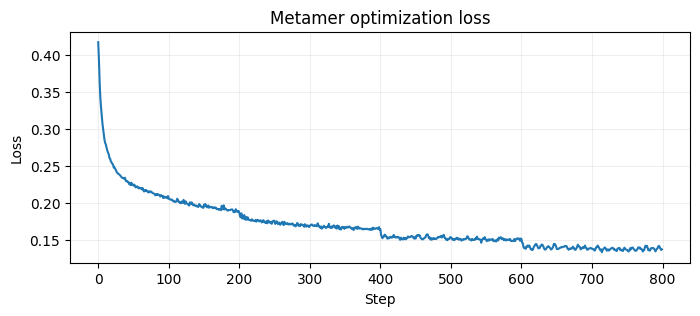

Final layer distance (L2): 26.047422409057617
Round summaries:
{'round': 0, 'lr': 0.25, 'avg_loss': 0.21734938144683838, 'final_step_loss': 0.18944863975048065}
{'round': 1, 'lr': 0.175, 'avg_loss': 0.17087584495544433, 'final_step_loss': 0.1641937643289566}
{'round': 2, 'lr': 0.12249999999999998, 'avg_loss': 0.15270813107490538, 'final_step_loss': 0.1525031477212906}
{'round': 3, 'lr': 0.08574999999999998, 'avg_loss': 0.13953531838953495, 'final_step_loss': 0.13783706724643707}
Original audio:


Metamer audio:


In [14]:
# Block 9: diagnostics (loss curve, representation distance, audio listen-back)
if len(loss_history) == 0:
    raise RuntimeError("No optimization history found. Run Block 8 first.")

loss_values = [item["loss"] for item in loss_history]

plt.figure(figsize=(8, 3))
plt.plot(loss_values)
plt.title("Metamer optimization loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.2)
plt.show()

if metamer.dim() == 3 and metamer.shape[1] == 1:
    metamer = metamer.squeeze(1)
with torch.no_grad():
    _, final_reps = model.forward_with_representations(metamer, sr=file_sr)
final_rep = final_reps[layer_name]
final_distance = torch.norm(final_rep - target_rep).item()

# Convert [B,T] -> [B,1,T] for unified preview/saving paths.
metamer_waveform = metamer.unsqueeze(1)

print("Final layer distance (L2):", final_distance)
print("Round summaries:")
for item in round_summaries:
    print(item)

print("Original audio:")
display(Audio(original_waveform[0, 0].detach().cpu().numpy(), rate=file_sr))
print("Metamer audio:")
display(Audio(metamer_waveform[0, 0].detach().cpu().numpy(), rate=file_sr))

In [ ]:
# Block 10: save artifacts (audio, tensors, metadata)
layer_dir = OUTPUT_ROOT / layer_name / RUN_TAG
layer_dir.mkdir(parents=True, exist_ok=True)

# Save tensors in [B,1,T] form
torch.save(original_waveform.detach().cpu(), layer_dir / "original_waveform.pt")
torch.save(metamer_waveform.detach().cpu(), layer_dir / "metamer_waveform.pt")

# Save playable waveforms with scipy.io.wavfile
original_np = original_waveform.detach().cpu().squeeze(0).squeeze(0).numpy()
metamer_np = metamer_waveform.detach().cpu().squeeze(0).squeeze(0).numpy()

original_int16 = np.clip(original_np, -1.0, 1.0)
original_int16 = (original_int16 * 32767.0).astype(np.int16)
metamer_int16 = np.clip(metamer_np, -1.0, 1.0)
metamer_int16 = (metamer_int16 * 32767.0).astype(np.int16)

wavfile.write(str(layer_dir / "original.wav"), int(file_sr), original_int16)
wavfile.write(str(layer_dir / "metamer.wav"), int(file_sr), metamer_int16)

# Save metadata
metadata = {
    "input_source": INPUT_SOURCE,
    "source_info": source_info,
    "model_input_shape": list(original_waveform_model.shape),
    "file_sr": int(file_sr),
    "device": DEVICE,
    "audio_model_name": AUDIO_MODEL_NAME,
    "layer_name": layer_name,
    "seed": int(SEED),
    "loss_type": LOSS_TYPE,
    "lr": float(LR),
    "num_rounds": int(NUM_ROUNDS),
    "steps_per_round": int(STEPS_PER_ROUND),
    "lr_decay": float(LR_DECAY),
    "noise_scale": float(NOISE_SCALE),
    "noise_mean": float(NOISE_MEAN),
    "clamp_min": float(CLAMP_MIN),
    "clamp_max": float(CLAMP_MAX),
    "elapsed_seconds": float(run_elapsed),
    "final_l2_distance": float(final_distance),
    "round_summaries": round_summaries,
}

with open(layer_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

with open(layer_dir / "loss_history.json", "w") as f:
    json.dump(loss_history, f)

print("Saved artifacts to:", layer_dir)